# Formula 1 Race Winner Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support, accuracy_score, f1_score

os.makedirs('out/images', exist_ok=True)

## Load the Data
We load all the CSV files from the `data` directory.

In [2]:
circuits = pd.read_csv('data/circuits.csv')
constructor_results = pd.read_csv('data/constructor_results.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')
constructors = pd.read_csv('data/constructors.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
drivers = pd.read_csv('data/drivers.csv')
lap_times = pd.read_csv('data/lap_times.csv')
pit_stops = pd.read_csv('data/pit_stops.csv')
qualifying = pd.read_csv('data/qualifying.csv')
races = pd.read_csv('data/races.csv')
results = pd.read_csv('data/results.csv')
seasons = pd.read_csv('data/seasons.csv')
sprint_results = pd.read_csv('data/sprint_results.csv')
status = pd.read_csv('data/status.csv')

# Merge into a single dataframe
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'date']], on='raceId')
df = df.merge(drivers[['driverId', 'driverRef', 'nationality', 'dob']], on='driverId')
df = df.merge(constructors[['constructorId', 'constructorRef', 'nationality']], on='constructorId', suffixes=('_driver', '_constructor'))
df = df.merge(circuits[['circuitId', 'circuitRef', 'country', 'lat', 'lng']], on='circuitId')
df = df.merge(status[['statusId', 'status']], on='statusId', how='left')

print(f"Main Dataframe Shape: {df.shape}")

Main Dataframe Shape: (26759, 32)


## Data Preprocessing
- Handle missing values (replace mapped `\N` with NaN)
- Convert data types (dates, numerics)

In [3]:
# Replace '\N' with NaN
df.replace('\\N', np.nan, inplace=True)

# Convert date columns
df['date'] = pd.to_datetime(df['date'])
df['dob'] = pd.to_datetime(df['dob'])

# Convert numeric columns that might be strings
numeric_cols = ['grid', 'positionOrder', 'points', 'laps']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaNs if appropriate (e.g. 0 points)
df['points'].fillna(0, inplace=True)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   resultId                 26759 non-null  int64         
 1   raceId                   26759 non-null  int64         
 2   driverId                 26759 non-null  int64         
 3   constructorId            26759 non-null  int64         
 4   number                   26753 non-null  str           
 5   grid                     26759 non-null  int64         
 6   position                 15806 non-null  str           
 7   positionText             26759 non-null  str           
 8   positionOrder            26759 non-null  int64         
 9   points                   26759 non-null  float64       
 10  laps                     26759 non-null  int64         
 11  time                     7680 non-null   str           
 12  milliseconds             7680 non-null   st

C:\Users\isula\AppData\Local\Temp\ipykernel_32788\2784997595.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['points'].fillna(0, inplace=True)


## Exploratory Data Analysis (EDA)
Visualizing the data and saving plots to `out/images`.

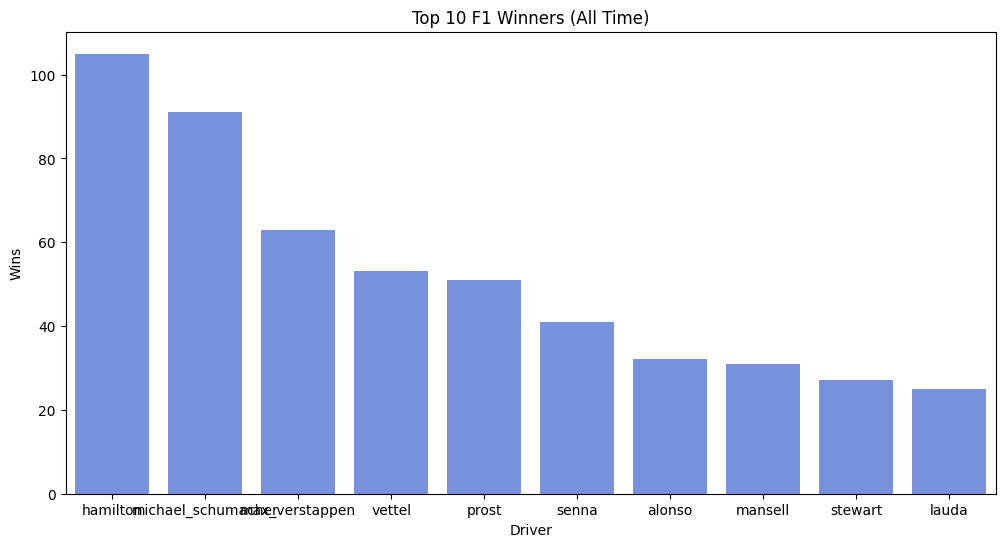

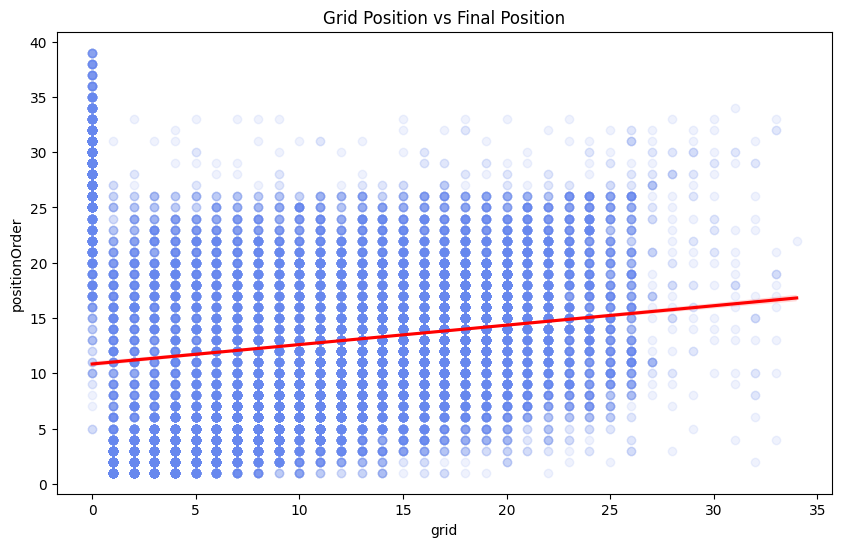

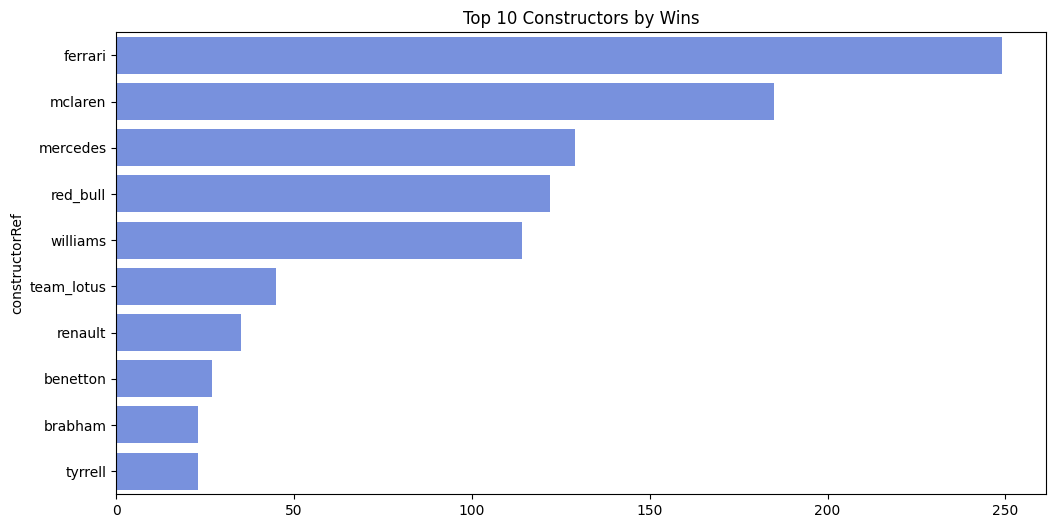

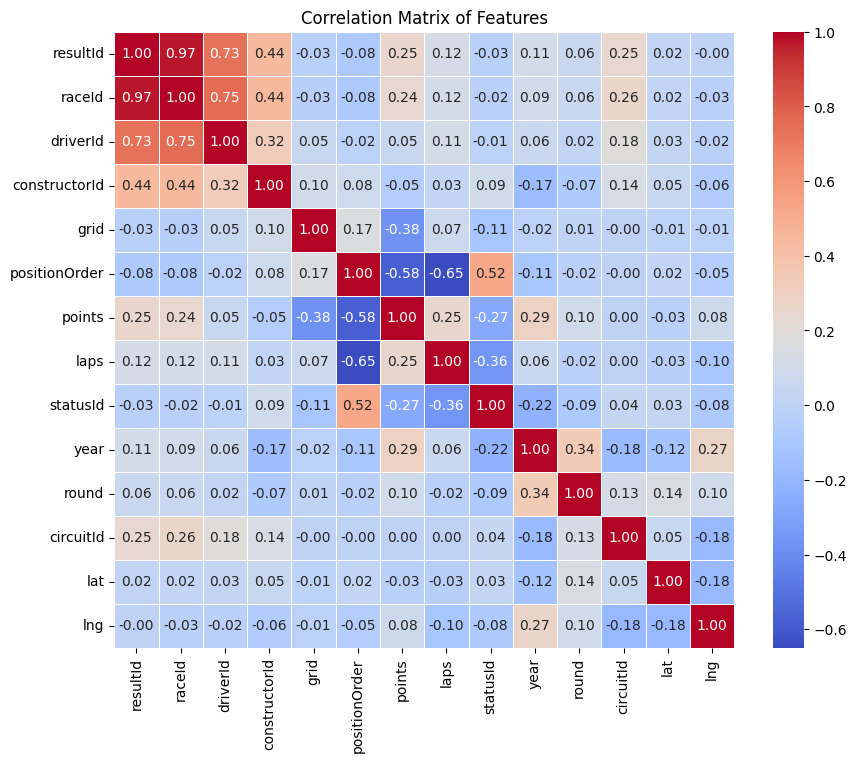

In [4]:
sns.set_palette("coolwarm")

# 1. Top 10 Winners
plt.figure(figsize=(12, 6))
top_winners = df[df['positionOrder'] == 1]['driverRef'].value_counts().head(10)
sns.barplot(x=top_winners.index, y=top_winners.values)
plt.title('Top 10 F1 Winners (All Time)')
plt.ylabel('Wins')
plt.xlabel('Driver')
plt.savefig('out/images/top_winners.png')
plt.show()

# 2. Grid Position vs Final Position Correlation
plt.figure(figsize=(10, 6))
correlation_data = df[['grid', 'positionOrder']].dropna()
sns.regplot(x='grid', y='positionOrder', data=correlation_data, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Grid Position vs Final Position')
plt.savefig('out/images/grid_pos_correlation.png')
plt.show()

# 3. Constructor Wins
plt.figure(figsize=(12, 6))
top_constructors = df[df['positionOrder'] == 1]['constructorRef'].value_counts().head(10)
sns.barplot(x=top_constructors.values, y=top_constructors.index, orient='h')
plt.title('Top 10 Constructors by Wins')
plt.savefig('out/images/constructor_wins.png')
plt.show()

# 4. Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.savefig('out/images/correlation_matrix.png')
plt.show()

## Feature Engineering
Creating features for the model.
- `Driver Age`: Age of driver at race date
- `Target`: 1 if winner (`positionOrder` == 1), else 0

In [5]:
# Calculate Driver Age
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# Create Target Variable
df['is_winner'] = df['positionOrder'].apply(lambda x: 1 if x == 1 else 0)

# Calculate Rolling Statistics (Pre-race features)
df = df.sort_values(['year', 'round'])
def calculate_rolling_stats(df, group_col, target_col, window=5):
    return df.groupby(group_col)[target_col].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )

df['driver_recent_points'] = calculate_rolling_stats(df, 'driverId', 'points')
df['constructor_recent_points'] = calculate_rolling_stats(df, 'constructorId', 'points')
df['driver_recent_position'] = calculate_rolling_stats(df, 'driverId', 'positionOrder')

# Imputation Strategy: Use Median for missing values (Neutral start instead of 0)
for col in ['driver_recent_points', 'constructor_recent_points', 'driver_recent_position']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Encode Categorical Variables
le_driver = LabelEncoder()
le_constructor = LabelEncoder()
le_circuit = LabelEncoder()

df['driverId_enc'] = le_driver.fit_transform(df['driverRef'])
df['constructorId_enc'] = le_constructor.fit_transform(df['constructorRef'])
df['circuitId_enc'] = le_circuit.fit_transform(df['circuitRef'])

# Select Features
features = ['grid', 'driverId_enc', 'constructorId_enc', 'circuitId_enc', 'driver_age', 'driver_recent_points', 'constructor_recent_points', 'driver_recent_position']
target = 'is_winner'

df_model = df[features + [target, 'year']].dropna()
print(df_model.head())

       grid  driverId_enc  constructorId_enc  circuitId_enc  driver_age  \
20024     1           249                  3             63   43.534565   
20025     2           246                  3             63   51.923340   
20026     4           663                  3             63   38.863792   
20027     6           136                 95             63   45.593429   
20028     9           690                 95             63   44.517454   

       driver_recent_points  constructor_recent_points  \
20024                   0.6                        0.6   
20025                   0.6                        9.0   
20026                   0.6                        7.5   
20027                   0.6                        0.6   
20028                   0.6                        3.0   

       driver_recent_position  is_winner  year  
20024                    12.4          1  1950  
20025                    12.4          0  1950  
20026                    12.4          0  1950  
2002

## Split Data
We use a temporal split to avoid data leakage (training on future races to predict past ones).
- **Train**: Races before 2023
- **Test**: Races in 2023 and after

In [6]:
train = df_model[df_model['year'] < 2023]
test = df_model[df_model['year'] >= 2023]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (25840, 8), Test shape: (919, 8)


## Choose Model & Hyperparameter Tuning
We will use a Random Forest Classifier. Given the class imbalance (1 winner vs 19 losers), we can use `class_weight='balanced'`.
We'll do a simple GridSearch to optimize.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Define models to train with Pipeline
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Hyperparameter tuning for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

results = []
best_model_name = ""
best_f1 = 0
best_model = None

print("Training models...")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Standard fit for all models (GridSearch temporarily removed due to environment issues)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except:
        roc = 0
        
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'ROC-AUC': roc
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = model

print("\nModel Comparison:")
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1-Score', ascending=False))

print(f"\nBest Model: {best_model_name} with F1-Score: {best_f1:.4f}")

Training models...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


Training XGBoost...
Training Gradient Boosting...


D:\Program Files\Programming\Python3.11\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:26:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Comparison:
                 Model  Accuracy  F1-Score   ROC-AUC
4    Gradient Boosting  0.964091  0.959612  0.965910
0  Logistic Regression  0.964091  0.958994  0.953982
2        Random Forest  0.964091  0.956907  0.953534
3              XGBoost  0.959739  0.956575  0.956298
1        Decision Tree  0.930359  0.932371  0.664737

Best Model: Gradient Boosting with F1-Score: 0.9596


## Make Predictions and Evaluate

Evaluating models on Train and Test sets...



Model Comparison (Check for Overfitting):
                 Model  Train Acc  Test Acc  Train F1   Test F1  Test ROC-AUC
4    Gradient Boosting   0.963351  0.964091  0.954156  0.959612      0.965910
0  Logistic Regression   0.959094  0.964091  0.944086  0.958994      0.953982
2        Random Forest   0.999961  0.964091  0.999961  0.956907      0.953534
3              XGBoost   0.985565  0.959739  0.984399  0.956575      0.956298
1        Decision Tree   1.000000  0.930359  1.000000  0.932371      0.664737

Best Model: Gradient Boosting with Test F1-Score: 0.9596

Detailed Evaluation for Gradient Boosting:
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       873
           1       0.74      0.43      0.55        46

    accuracy                           0.96       919
   macro avg       0.86      0.71      0.76       919
weighted avg       0.96      0.96      0.96       919

ROC AUC Score: 0.9659


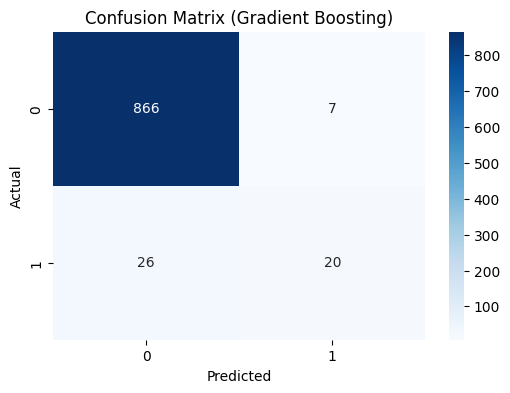

In [8]:
results = []
best_model_name = ""
best_f1 = 0
best_model = None

print("Evaluating models on Train and Test sets...")
for name, model in models.items():
    # Test Set Metrics
    y_pred_test = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    # Train Set Metrics (to check for overfitting)
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    
    try:
        y_prob_test = model.predict_proba(X_test)[:, 1]
        roc_test = roc_auc_score(y_test, y_prob_test)
    except:
        roc_test = 0
        
    results.append({
        'Model': name,
        'Train Acc': acc_train,
        'Test Acc': acc_test,
        'Train F1': f1_train,
        'Test F1': f1_test,
        'Test ROC-AUC': roc_test
    })
    
    if f1_test > best_f1:
        best_f1 = f1_test
        best_model_name = name
        best_model = model

print("\nModel Comparison (Check for Overfitting):")
results_df = pd.DataFrame(results)
# Reorder columns for easier comparison
results_df = results_df[['Model', 'Train Acc', 'Test Acc', 'Train F1', 'Test F1', 'Test ROC-AUC']]
print(results_df.sort_values(by='Test F1', ascending=False))

print(f"\nBest Model: {best_model_name} with Test F1-Score: {best_f1:.4f}")

# Detailed Evaluation of the Best Model
print(f"\nDetailed Evaluation for {best_model_name}:")
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('out/images/confusion_matrix.png')
plt.show()

## Saving Model

In [9]:
model_data = {
    'model': best_model,
    'le_driver': le_driver,
    'le_constructor': le_constructor,
    'le_circuit': le_circuit,
    'feature_names': features
}

joblib.dump(model_data, 'out/models/f1_model_data.pkl')
print("Model saved to 'out/models/f1_model_data.pkl'")

Model saved to 'out/models/f1_model_data.pkl'


## Deploying in WebApp

To run the app, execute the following command in your terminal:

```bash
python app.py
```